In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
import pickle

# Load final dataset
data = pd.read_csv("data_cleaned.csv")

# Features and target
X = data[['temperature_2m', 'relative_humidity_2m', 'wind_speed_10m', 'ndvi']]
y = data['pm2.5']

In [4]:
import os

# Train test split
# First, handle NaN values in y
nan_mask = y.isna()
X_cleaned = X[~nan_mask]
y_cleaned = y[~nan_mask]

X_train, X_test, y_train, y_test = train_test_split(X_cleaned, y_cleaned, test_size=0.2)

# Train model
model = RandomForestRegressor()
model.fit(X_train, y_train)

# Save model
os.makedirs('../model', exist_ok=True)
pickle.dump(model, open("../model/model.pkl", "wb"))

print("Model trained and saved.")

Model trained and saved.


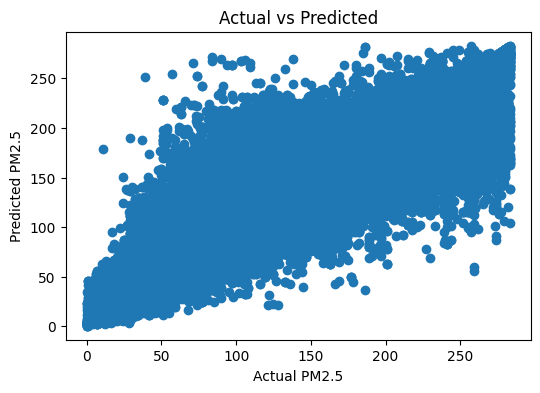

In [6]:
import os

# Plot prediction vs actual
y_pred = model.predict(X_test)

plt.figure(figsize=(6,4))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual PM2.5")
plt.ylabel("Predicted PM2.5")
plt.title("Actual vs Predicted")
os.makedirs('../images', exist_ok=True)
plt.savefig("../images/model_training_plot.png")
plt.show()